# <span style="color: yellow;">Master Notebook</span>

This notebook contains our entire project, and should be capable of running from start to end without issue.  It has three main sections - one for our application of algorithms to the pretrained ResNet50, one for ResNet 18, and one for ResNet10t.  In each section, there will be sub-sections for each compression algorithm, and the results will be plotted at the end on a Pareto front.

Please paste your functions applying your compression technique in the appropriate section.  The final deliverable is a <ins>Pareto Front</ins> graph, so what you need to output from your model is its <ins>% size reduction</ins> (how much you decreased parameters) and <ins>F1 accuracy</ins> at that size.

**Table of Contents:**
1. Data Preparation: this section pulls the necessary dataset from huggingface and instantiates a pytorch dataset/loaders
2. Application of algorithms to ResNet50
3. Application of algorithms to ResNet18
4. Application of algorithms to ResNet10t
5. Appendix

Within each of these application sections, there will be sub-sections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [1]:
# first we just ensure we are working in the right folder
import os
target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/cc65/CS6423_knowledge_distillation_project


## <span style="color: yellow;">1. Data Preparation</span>

This code downloads the dataset and pretrained models from HuggingFace and does a bit of cleaning. You will need to put a HF token with access to the required repositories into the first cell.  <span style="color: yellow;">Note: you only need to run these download cells once (or not at all if you already downloaded dataset)</span>

In [2]:
# Fiachra - code that downloads the dataset and organizes the csv.
from huggingface_hub import login
login("your hf token here")

HfHubHTTPError: Invalid user token.

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os

SAVE_DIR = "data/test_images"
NUM_TEST_IMGS = 10000
os.makedirs(SAVE_DIR, exist_ok=True)

ds = load_dataset(
    "raidium/RadImageNet-VQA",
    "alignment",
    split="val",
    streaming=True
)

subset = ds.shuffle(seed=42, buffer_size=30000).take(NUM_TEST_IMGS)

seen_images = set()
labels_path = "data/labels.csv"

with open(labels_path, "w", encoding="utf-8") as f:
    f.write("filename,pathology,modality,location,label\n")

    for i, row in enumerate(tqdm(subset, desc="Saving unique images", total=NUM_TEST_IMGS)):
        if not isinstance(row, dict):
            continue

        img_id = row.get("id", i)

        if img_id not in seen_images:
            img_filename = f"test_{img_id}.png"
            img_path = os.path.join(SAVE_DIR, img_filename)

            if not os.path.exists(img_path):
                row["image"].save(img_path)

            meta = row.get("metadata", {})
            pathology = meta.get("pathology", "unknown")
            modality = meta.get("modality", "unknown")
            location = meta.get("location", "unknown")
            label = f"{location}_{pathology}".replace(" ", "_")

            f.write(f"{img_filename},{pathology},{modality},{location},{label}\n")
            seen_images.add(img_id)

print(f"\nProcessing Complete!")
print(f"Total Unique Images: {len(seen_images)}")
print(f"Metadata saved to: {labels_path}")

In [ ]:
import pandas as pd

test_df = pd.read_csv("data/labels.csv")
label_counts = test_df['label'].value_counts()
label_counts.plot(kind='bar', title='Class Distribution in Dataset')

large_classes = label_counts[label_counts > 10].index
drop_classes_df = test_df[test_df['label'].isin(large_classes)]
num_classes = drop_classes_df.label.value_counts().shape[0]

print(f"total number of classes in dataset: {num_classes}")
print(f"total datapoints in dataset: {len(drop_classes_df)}")
drop_classes_df.to_csv("data/labels.csv", index=False)
df = pd.read_csv('data/labels.csv')

df.head()

Here we prepare the dataset using Fiachra's modules.  <span style="color: yellow;">This cell needs to be run every time.</span>

In [3]:
# Fiachra - instantiate the dataset/dataloaders through the datasetPrepper
import pandas as pd
from modules.dataset_prepper import datasetPrepper

# sets path variables
pretrained_weights_path = "RadImageNet_weights/resnet50.pth"
dataframe_path = "data/labels.csv"
image_dir = "data/test_images"
model_name = "resnet50_baseline_cpu"

# loads dataset csv
dataframe = pd.read_csv(dataframe_path)
num_classes = dataframe["label"].nunique()

# prepare dataset with datasetPrepper module, print confirmations
data_prep = datasetPrepper(
    dataframe_path="data/labels.csv",
    image_dir="data/test_images",
).prepare(compute_class_weights=True)

print(f"Dataset prepared:")
print(f"  Train samples: {len(data_prep.train_dataset)}")
print(f"  Val samples: {len(data_prep.val_dataset)}")
print(f"  Test samples: {len(data_prep.test_dataset)}")
print(f"  Classes: {len(data_prep.class_names)}")

Dataset prepared:
  Train samples: 7948
  Val samples: 1590
  Test samples: 398
  Classes: 61


# <span style="color: yellow;">Algorithm Application to ResNet50</span>
This section applied all of our KD algorithms to a pretrained ResNet50.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: yellow;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [4]:
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="fiabar/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

'/home/cc65/CS6423_knowledge_distillation_project/trained_models'

Here we instantiate the pretrained ResNet50 and run an inference pass for the baseline.

In [5]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet50 = resnet50.to(device)
resnet50.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet50.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet50, "ResNet50 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet50 gpu new...
Running inference...
Our F1 score: 0.05708919581063307
Our total parameters: 23633021


/home/cc65/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style="color: yellow;">b. Basic Compression Algorithms</span>

### Initializing our experiment tracker
Here we define a function that can append the results from each model compression algorithm to a dataframe for our Pareto Front visualization.  The tracker has:
* method: the method you used for compression (e.g., LTH, RGP, NAS+KD, etc.)
* base_model: the name of the model you are compressing (e.g., resnet10, resnet18, resnet50) 
* base_size: the number of parameters in the basic model
* compressed_size: the number of parameters in the model you compressed
* f1: the F1 score your compressed model has 

So, after you run each experiment, have something that looks like:

In [6]:
'''
Method = 'Pruning'
Base_Model = 'resnet10'
Base_Model_Parameters = 2012345
New_Model_Parameters = 2002345
F1_Score = 0.8
add_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)
'''

"\nMethod = 'Pruning'\nBase_Model = 'resnet10'\nBase_Model_Parameters = 2012345\nNew_Model_Parameters = 2002345\nF1_Score = 0.8\nadd_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)\n"

In [7]:
# initialize a dataframe we will append our results to
import pandas as pd
results_df = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet50', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.057


In [8]:
# Code or functions that apply basic pruning
from torch.nn.utils import prune
import copy

def random_prune(model, amount):
    # apply ranodm unstructured pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.random_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'randomized unstructured pruning applied with amount: {amount}')

def magnitude_prune(model, amount):
    # apply random magnitude pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.l1_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'magnitude pruning applied with amount: {amount}')


pruning_amounts = [0.1, 0.25, 0.5, 0.75, 0.9]
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

for amount in pruning_amounts:
    # initialize model copies
    model_random_pruned = copy.deepcopy(resnet50)
    model_magnitude_pruned = copy.deepcopy(resnet50)
    
    # apply prunings and record results
    random_prune(model_random_pruned, amount)
    metrics = evaluator.evaluate_single(model_random_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Random Pruning', 
                   base_model='resnet50',
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])
    
    magnitude_prune(model_magnitude_pruned, amount)
    metrics = evaluator.evaluate_single(model_magnitude_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Magnitude Pruning', 
                   base_model='resnet50', 
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])

display(results_df)

Logged: Random Pruning | Reduction: 10.0% | F1: 0.002


/home/cc65/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 10.0% | F1: 0.056


/home/cc65/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 24.9% | F1: 0.001


...

/home/cc65/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 74.8% | F1: 0.000


/home/cc65/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 74.8% | F1: 0.011
Logged: Random Pruning | Reduction: 89.8% | F1: 0.000
Logged: Magnitude Pruning | Reduction: 89.8% | F1: 0.003


,Method,Base_Model,Size_Reduction_Pct,F1_Score
0,N/A,resnet50,0.0,0.0571
1,Random Pruning,resnet50,9.98,0.0019
2,Magnitude Pruning,resnet50,9.98,0.0563
3,Random Pruning,resnet50,24.94,0.0008
4,Magnitude Pruning,resnet50,24.94,0.0574
5,Random Pruning,resnet50,49.89,0.0
6,Magnitude Pruning,resnet50,49.89,0.0542
7,Random Pruning,resnet50,74.83,0.0
8,Magnitude Pruning,resnet50,74.83,0.0109
9,Random Pruning,resnet50,89.8,0.0002


### Basic Pruning and Quantization

In [9]:
# Code or functions that apply quantization

### Caylum - Lottery Ticket Hypothesis
This is a varient of the lottery ticket hypothesis known as weight resetting. Essentially, since we cannot get access to the original weight initialisation, we use the weights prior to fine tuning on our data set as the initial weights, and use those as the original weights.

In [10]:
# For ease, we set weights to zero instead of removing them outright so we use this function to count effective paramaters.
def count_effective_params(model):
    total = 0
    nonzero = 0
    
    for p in model.parameters():
        total += p.numel()
        nonzero += (p != 0).sum().item()
    
    return total, nonzero

In [12]:
import torch as T
import torch.nn.utils.prune as prune
from torchvision import models
import numpy as np
from modules import ImagenetLoader, datasetPrepper, modelTrainer, ModelEvaluator
import pandas as pd


# We need the weights path
lth_pretrained_weights_path = "RadImageNet_weights/resnet50.pth"

# Define the evaluator
lth_evaluator = ModelEvaluator(data_prep.val_loader, data_prep.class_names)
lth_loader = ImagenetLoader()
lth_eval_stats = {}
lth_param_counts = {}

# Define the pruning percentages
pruning_percentages = [10, 25, 50, 75, 90]

# Now loop for all pruning percentages
for p_percent in pruning_percentages:
    print(f"\nLTH for {p_percent}%")
    
    # Reset Weights at the start of every cycle
    lth_loader.load_radimagenet_resnet50(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    
    # Train the parent model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"parent_lth_{p_percent}",
    )
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()
    
    # Get the pruning mask from the parent model
    lth_model.eval()
    masks = {}
    
    for name, module in lth_model.named_modules():
      if isinstance(module, (T.nn.Linear, T.nn.Conv2d)):
        prune.l1_unstructured(module, name='weight', amount=p_percent / 100.0)
        masks[name] = (module.weight_mask).cpu()
        prune.remove(module, 'weight')

    # Reset Weights
    lth_loader.load_radimagenet_resnet50(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"lth_{p_percent}",
    )

    # Apply the mask by directly setting weights to zero where mask is zero
    with T.no_grad():
      for name, module in lth_model.named_modules():
        if isinstance(module, (T.nn.Linear, T.nn.Conv2d)) and name in masks:
            module.weight.data.mul_(masks[name])
            prune.custom_from_mask(module, name='weight', mask=masks[name])
            prune.remove(module, 'weight')
    
    # Train that ticket
    print(f"Training ticket for {p_percent}% LTH pruning...")
    lth_model.train()
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()

    # Evaluate that ticket
    lth_model.eval()
    lth_metrics = lth_evaluator.evaluate_single(lth_model)
    lth_total, lth_non_zero = count_effective_params(lth_model)
    
    # Add in the experiment
    add_experiment(method=f'LTH {p_percent}', 
               base_model='resnet50', 
               base_size=lth_total, 
               compressed_size=lth_non_zero, 
               f1=lth_metrics['f1_macro'])

    print(f"\n======================\nDone for %{p_percent}\n======================\n")


LTH for 10%


Validating: 100%|██████████| 50/50 [00:03<00:00, 15.45batch/s]



Epoch 1/10
Train Loss: 2.4813 | Train F1: 0.0936
Val Loss: 5.2681 | Val F1: 0.0124
Epoch Time: 36.68s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.95batch/s]



Epoch 2/10
Train Loss: 1.5333 | Train F1: 0.2051
Val Loss: 5.5053 | Val F1: 0.0119
Epoch Time: 36.27s



...


Epoch 8/10
Train Loss: 2.2172 | Train F1: 0.0933
Val Loss: 5.6191 | Val F1: 0.0019
Epoch Time: 36.33s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.97batch/s]



Epoch 9/10
Train Loss: 2.0616 | Train F1: 0.1086
Val Loss: 5.9940 | Val F1: 0.0020
Epoch Time: 36.34s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.86batch/s]



Epoch 10/10
Train Loss: 1.9522 | Train F1: 0.1223
Val Loss: 5.6924 | Val F1: 0.0054
Epoch Time: 36.32s


Warming up Model...
Running inference...
Logged: LTH 90 | Reduction: 32.9% | F1: 0.005

Done for $90



### Kellie - RGP
Code/functions that apply RGP and output a few datapoints for the Pareto Front. RGP iteratively removes the least important convolution filters from ResNet50 using gradient-based importane scorea, sheinking the model in 5 steps from 10% to 50% sparsity. After each pruning step the model is fine-tunes to recover accuracy, trading off model size against F1 score acrpss 5 Pareto front points.

In [7]:
# Kellie - RGP: Rigorous Gradient-based Pruning
# Results loaded from pre-trained checkpoints saved by rgp.ipynb
# Models were trained with iterative structured pruning (DFOT scoring) across
# 5 sparsity levels (10%-50%), fine-tuned for 10 epochs each to recover accuracy.

import os
import torch
import pandas as pd

rgp_checkpoints = {
    '10%': 'trained_models/rgp_step_0.1/rgp_step_0.1_full.pth',
    '20%': 'trained_models/rgp_step_0.2/rgp_step_0.2_full.pth',
    '30%': 'trained_models/rgp_step_0.3/rgp_step_0.3_full.pth',
    '40%': 'trained_models/rgp_step_0.4/rgp_step_0.4_full.pth',
    '50%': 'trained_models/rgp_step_0.5/rgp_step_0.5_full.pth',
}

initial_params = sum(p.numel() for p in resnet50.parameters())
rgp_step_metrics = []

for sparsity, path in rgp_checkpoints.items():
    print(f"Loading RGP {sparsity} model from {path}...")

    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()

    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())

    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    rgp_step_metrics.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# Results summary table
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)

Loading RGP 10% model from trained_models/rgp_step_0.1/rgp_step_0.1_full.pth...
Logged: RGP | Reduction: 4.5% | F1: 0.305
Loading RGP 20% model from trained_models/rgp_step_0.2/rgp_step_0.2_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 7.2% | F1: 0.295
Loading RGP 30% model from trained_models/rgp_step_0.3/rgp_step_0.3_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 10.0% | F1: 0.285
Loading RGP 40% model from trained_models/rgp_step_0.4/rgp_step_0.4_full.pth...


...

Logged: RGP | Reduction: 12.6% | F1: 0.290
Loading RGP 50% model from trained_models/rgp_step_0.5/rgp_step_0.5_full.pth...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 14.9% | F1: 0.301


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.53,0.3054,86.3,1.05
20%,7.16,0.2954,83.9,1.02
30%,10.01,0.2850,81.3,1.05
40%,12.64,0.2901,79.0,1.03
50%,14.94,0.3012,76.9,1.03


## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>


### Ethan - NAS + KD Algorithm
Here, we employ our NAS+KD algorithm.  The step-by-step process will only be shown for the ResNet50 - we will only import the weights of the final student for the ResNet18 and ResNet10t.  Training logs for those models are included at the very end of the notebook, in the Appendix section.\

The algorithm has the following steps:\
**1) Define a Search Space**: in the form of a SupernetConfig class\
**2) Construct a Supernet**: with the imported supernet_resnet50 function from the knowledge_distillation.model_init custom module\
**3) KD to train the Supernet with GreedyNAS**: done through the main() function that orchestrates training\
**4) Evolutionary Algorithm to Select the Final Student**: orchestrated through imported modules from knowledge_distillation.evolutionary_search\
**5) Fine Tune the Student:** for 30 epochs

All of this is shown below, and in the final cell, the weights from the trained student are imported and inference is performed.  As such, <span style="color: yellow;">**only the last cell of my section needs to be run to add the NAS+KD experiment to the pareto Front graph.**</span>

In [8]:
''' search space:
input resolution = [128, 160, 190, 224]
depth = [2, 3, 4]
width = [0.65, 0.8, 1.0, 1.2]
expansion ratio = [3,4,6]
'''
# define a ocnfig class for supernet training
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet50'

        # supernet init params
        self.supernet_res = [128, 160, 190, 224]
        self.supernet_width = [0.65, 0.8, 1.0, 1.2]
        self.supernet_expansion = [1.5, 2.0, 3.0]
        self.supernet_depth = [2, 3]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 3.0
        self.alpha = 0.5
        
        self.saver = 'supernet_resnet50_n'

In [78]:
import torch.optim as optim
from torch.optim.lr_scheduler import ConstantLR, CosineAnnealingLR, SequentialLR, LinearLR

# main function to orchestrate supernet training - all the functions will be pulled from knowledge_distillation folder
def main(config, snet, optimizer, scheduler, start_epoch=0):
    train_loader = data_prep.train_loader
    val_loader = data_prep.val_loader
    best_val_f1 = 0.0
    
    for epoch in range(start_epoch, config.epochs):        
        stats, phase = train_supernet(snet, 
                                      resnet50,  # this is where we pass teacher
                                      config, 
                                      train_loader, 
                                      optimizer, 
                                      epoch)  # weights distillation loss
        
        # validate every 5 epochs
        if (epoch + 1) % 5 == 0:
            val_stats = validate_supernet(snet, train_loader, val_loader, config)
            print(f"--- VALIDATION Epoch {epoch} ---")
            print(f"MAX Path: Acc {val_stats['MAX']['accuracy']:.2f}% | Loss {val_stats['MAX']['avg_loss']:.4f} | F1: {val_stats['MAX']['f1_macro']:.2f}")
            print(f"MIN Path: Acc {val_stats['MIN']['accuracy']:.2f}% | Loss {val_stats['MIN']['avg_loss']:.4f} | F1: {val_stats['MIN']['f1_macro']:.2f}")
            
            if val_stats['MAX']['f1_macro'] > best_val_f1:
                    print(f"New Best F1! Saving model...")
                    best_val_f1 = val_stats['MAX']['f1_macro']
                    # save the best version
                    save_path = f"{config.saver}_BEST_f1.pth"
                    # package it with optimizer and best f1 score
                    checkpoint = {
                        'epoch': epoch,
                        'model_state_dict': snet.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'f1_macro': best_val_f1
                    }
                    torch.save(checkpoint, save_path)

        scheduler.step()
        
        # report epoch stats
        print(f"Epoch {epoch} | {phase} | LR: {scheduler.get_last_lr()[0]:.6f} | Loss: {stats['avg_loss']:.4f} | KL (Soft): {stats['avg_kl']:.4f} | Accuracy: {stats['accuracy']:.2f}%  | F1: {stats['f1_macro']:.2f}")
        
        # save every 5 epochs if loss is improving
        if (epoch+1)%5 == 0:
            save_supernet(snet, f'{config.saver}_epoch_{epoch+1}.pth')

In [12]:
from knowledge_distillation.model_init import Supernet_resnet50, save_supernet
from knowledge_distillation.train_loop import DistillationLoss, sample_configs, train_supernet, validate_supernet
# initialize config class
config = SupernetConfig()

# initialize our supernet model
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes)
num_params = sum(p.numel() for p in snet.parameters())
print("Parameters:", num_params)
print("Estimated FP32 size:", num_params * 4 / 1024**3, "GB")  # estimates size of supernet

snet.to(config.device)
# print(Supernet)  # confirm object

# optimizer and LR scheduler
optimizer = optim.SGD(snet.parameters(), lr=0.01, momentum=0.9, weight_decay=4e-5)
scheduler_warmup = ConstantLR(optimizer, factor=1.0, total_iters=config.warmup_epochs) # keep LR constant over warmup epochs
scheduler_cosine = CosineAnnealingLR(optimizer, T_max=(config.epochs - config.warmup_epochs), eta_min=1e-4)  # decay 0.05 -> 0.0001
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine],  milestones=[config.warmup_epochs])

main(config, snet, optimizer, scheduler)

Parameters: 191075391
Estimated FP32 size: 0.7118113003671169 GB
Epoch 0 | warm | LR: 0.010000 | Loss: 7.1891 | KL (Soft): 10.0534 | Accuracy: 5.31%  | F1: 0.04
Epoch 1 | warm | LR: 0.010000 | Loss: 5.6747 | KL (Soft): 7.4816 | Accuracy: 13.05%  | F1: 0.11
Epoch 2 | warm | LR: 0.010000 | Loss: 5.0242 | KL (Soft): 6.4628 | Accuracy: 17.05%  | F1: 0.15
Epoch 3 | warm | LR: 0.010000 | Loss: 4.4930 | KL (Soft): 5.6275 | Accuracy: 20.89%  | F1: 0.18
Recalibrating BN for MAX path...
Recalibrating BN for MIN path...
--- VALIDATION Epoch 4 ---
MAX Path: Acc 15.85% | Loss 3.3740 | F1: 0.12
MIN Path: Acc 16.10% | Loss 3.4184 | F1: 0.12
New Best F1! Saving model...
Epoch 4 | warm | LR: 0.010000 | Loss: 4.2407 | KL (Soft): 5.2378 | Accuracy: 23.19%  | F1: 0.21
Epoch 5 | warm | LR: 0.010000 | Loss: 3.9974 | KL (Soft): 4.8863 | Accuracy: 27.14%  | F1: 0.24
Epoch 6 | warm | LR: 0.010000 | Loss: 3.7539 | KL (Soft): 4.4907 | Accuracy: 29.93%  | F1: 0.27
Epoch 7 | warm | LR: 0.010000 | Loss: 3.5780 | KL

In [87]:
from knowledge_distillation.model_init import Supernet_resnet50, save_supernet
import knowledge_distillation.evolutionary_search as es

config = SupernetConfig()
# define size limit - about the size of the current resnet50
PARAM_LIMIT = 25.0

# load best supernet weights from training
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location='cuda')
snet.load_state_dict(checkpoint['model_state_dict'])
snet.to('cuda')
snet.eval()

# intialize data loaders
train_loader = data_prep.train_loader
search_loader = data_prep.val_loader

# execute search
print(f"Starting Evolutionary Search")
best_architecture = es.run_evolutionary_search(
    snet, search_loader, train_loader, 'cuda', config,
    generations=10, 
    population_size=30, 
    param_limit=PARAM_LIMIT,    
)

print("\n--- Done Searching ---")
print(f"Final F1: {best_architecture['f1']:.4f}")
print(f"Final Size: {best_architecture['size']:.2f}M")
print(f"Best Config: {best_architecture['config']}")

Starting Evolutionary Search

--- Generation 0 ---
NEW BEST ARCHITECTURE
F1: 0.3277 | Size: 14.77M params
Config: {'res': 128, 'width': 0.65, 'depth': [2, 3, 3, 2], 'exp': [3.0, 3.0, 2.0, 1.5]}

--- Generation 1 ---
NEW BEST ARCHITECTURE
F1: 0.3357 | Size: 19.86M params
Config: {'res': 128, 'width': 0.8, 'depth': [3, 3, 2, 2], 'exp': [1.5, 3.0, 2.0, 1.5]}

--- Generation 2 ---
NEW BEST ARCHITECTURE
F1: 0.3451 | Size: 16.53M params
Config: {'res': 128, 'width': 0.65, 'depth': [2, 2, 3, 2], 'exp': [2.0, 3.0, 1.5, 2.0]}

--- Generation 3 ---

--- Generation 4 ---

--- Generation 5 ---

--- Generation 6 ---

--- Generation 7 ---

--- Generation 8 ---

--- Generation 9 ---
NEW BEST ARCHITECTURE
F1: 0.3492 | Size: 16.62M params
Config: {'res': 128, 'width': 0.65, 'depth': [3, 2, 3, 2], 'exp': [2.0, 3.0, 1.5, 2.0]}

--- Done Searching ---
Final F1: 0.3492
Final Size: 16.62M
Best Config: {'res': 128, 'width': 0.65, 'depth': [3, 2, 3, 2], 'exp': [2.0, 3.0, 1.5, 2.0]}


In [88]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import f1_score
from knowledge_distillation.train_loop import DistillationLoss

# specify the winning config from our evolutionary search!
winning_config = {
    'res': 128, 
    'width': 0.65, 
    'depth': [3, 2, 3, 2],
    'exp': [2.0, 3.0, 1.5, 2.0]
}

EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
ALPHA = 0.0
TEMPERATURE = 3.0

# intialize supernet and load trained weights
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")
for m in snet.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.momentum = 0.5  # adjust BN momentum to help it adjust quicker

# initialize teacher - this ends up not mattering, as I found an alpha set to zero leads to the best result through experiments
resnet50.to(config.device)
resnet50.eval()

# initialize optimizer, scheduler, loss function
optimizer = optim.AdamW(snet.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = DistillationLoss(alpha=ALPHA, T=TEMPERATURE)

def evaluate_f1(model, cfg, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(config.device), labels.to(config.device)
            # Match resolution
            if images.shape[-1] != cfg['res']:
                images = F.interpolate(images, size=(cfg['res'], cfg['res']), mode='bilinear')
            
            logits = model(images, cfg)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return f1_score(all_labels, all_preds, average='macro', zero_division=0)

# fine tuning loop
best_f1 = 0.0 # starting benchmark
for epoch in range(EPOCHS):
    snet.train()
    running_loss = 0.0
    
    for images, labels in data_prep.train_loader:
        images, labels = images.to(config.device), labels.to(config.device)
        
        # match winning config's resolution
        if images.shape[-1] != winning_config['res']:
            images = F.interpolate(images, size=(winning_config['res'], winning_config['res']), mode='bilinear')
        
        optimizer.zero_grad()
        
        # forward pass for teacher and student
        with torch.no_grad():
            teacher_logits = resnet50(images)
        student_logits = snet(images, winning_config)
        
        # loss and backprop
        loss, _ = criterion(student_logits, teacher_logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(snet.parameters(), max_norm=2.0)  # gradient clipping for stability
        optimizer.step()
        
        running_loss += loss.item()

    scheduler.step()
    
    snet.train()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(data_prep.train_loader):
            if i > 40: break # quick recalibration
            if imgs.shape[-1] != winning_config['res']:
                imgs = F.interpolate(imgs, size=(winning_config['res'], winning_config['res']), mode='bilinear')
            _ = snet(imgs.to(device), winning_config)

    # f1 evaluation on validation set
    current_f1 = evaluate_f1(snet, winning_config, data_prep.val_loader, config.device)
    avg_loss = running_loss / len(data_prep.train_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {current_f1:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    # save if we hit a new peak
    if current_f1 > best_f1:
        best_f1 = current_f1
        print(f"New Best Fine-Tuned F1: {best_f1:.4f}, Saving...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': snet.state_dict(),
            'config': winning_config,
            'f1_macro': best_f1
        }, f"{config.saver}_polished.pth")

print("\nThat's all.")

Supernet loaded
Epoch 1/30 | Loss: 1.6326 | Val F1: 0.3351 | LR: 0.000100
New Best Fine-Tuned F1: 0.3351, Saving...
Epoch 2/30 | Loss: 1.5207 | Val F1: 0.3469 | LR: 0.000099
New Best Fine-Tuned F1: 0.3469, Saving...
Epoch 3/30 | Loss: 1.4533 | Val F1: 0.3392 | LR: 0.000098
Epoch 4/30 | Loss: 1.4158 | Val F1: 0.3420 | LR: 0.000096
Epoch 5/30 | Loss: 1.3725 | Val F1: 0.3544 | LR: 0.000093
New Best Fine-Tuned F1: 0.3544, Saving...
Epoch 6/30 | Loss: 1.3466 | Val F1: 0.3551 | LR: 0.000090
New Best Fine-Tuned F1: 0.3551, Saving...
Epoch 7/30 | Loss: 1.2898 | Val F1: 0.3501 | LR: 0.000087
Epoch 8/30 | Loss: 1.2739 | Val F1: 0.3706 | LR: 0.000083
New Best Fine-Tuned F1: 0.3706, Saving...
Epoch 9/30 | Loss: 1.2395 | Val F1: 0.3799 | LR: 0.000079
New Best Fine-Tuned F1: 0.3799, Saving...
Epoch 10/30 | Loss: 1.2137 | Val F1: 0.3659 | LR: 0.000075
Epoch 11/30 | Loss: 1.1786 | Val F1: 0.3557 | LR: 0.000070
Epoch 12/30 | Loss: 1.1806 | Val F1: 0.3700 | LR: 0.000065
Epoch 13/30 | Loss: 1.1560 | Val 

This is the final cell - the only one you need to run to add the experiment.  It imports the trained, evolved, and fine tuned student model for final testing.


In [9]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet50
from knowledge_distillation.extraction_tools import extract_resnet50, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'supernet_resnet50_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.65, 
    'depth': [3, 2, 3, 2],
    'exp': [2.0, 3.0, 1.5, 2.0]
}

# extract our winning configuration from the supernet and confirm it loaded appropriately
student_r50 = extract_resnet50(snet, winning_config)
verify_parity(snet, student_r50, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(student_r50)
print(f'\nStudent has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet50',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])

Supernet loaded
Slicing weights...
The models match! Test is passed.
Max difference: 9.54e-07

Student has parameters: 16621975
Logged: NAS+KD | Reduction: 29.7% | F1: 0.388


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD
A few sentences to describe your method, then your code

In [31]:
# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

## <span style="color: yellow;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

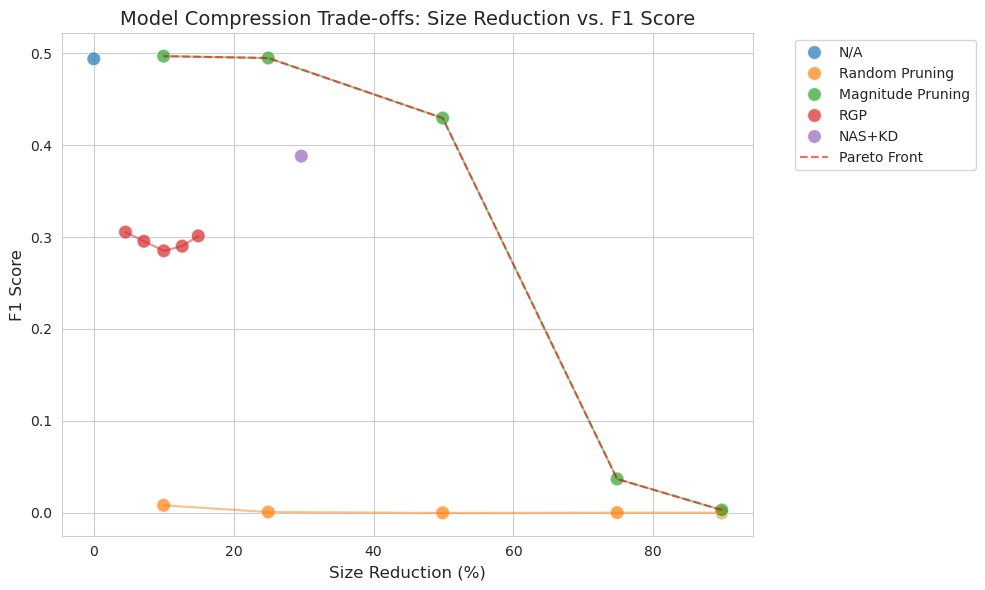

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df)

In [11]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df.to_csv("results_resnet50.csv", mode='a', header=False, index=False)

# <span style="color: green;">Algorithm Application to ResNet18</span>
This section applied all of our KD algorithms to a pretrained ResNet18.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: green;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [12]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet18 = loader.load_radimagenet_resnet18(
    "./trained_models/resnet18_baseline_gpu_new/resnet18_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet18 = resnet18.to(device)
resnet18.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet18.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet18, "ResNet18 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet18 gpu new...
Running inference...
Our F1 score: 0.4110675749183641
Our total parameters: 11207805


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
# initialize a dataframe we will append our results to
results_df_resnet18 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df_resnet18
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df_resnet18 = pd.concat([results_df_resnet18, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet18', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.411


## <span style="color: green;">b. Basic Compression Algorithms</span>

### Basic Pruning and Quantization

### Caylum - Lottery Ticket Hypothesis

### Kellie - RGP

## <span style="color: green;">c. Knowledge Distillation Algorithms</span>

### Ethan - NAS + KD Algorithm

In [14]:
''' search space:
input resolution = [128, 160, 190, 224]
depth = [1, 2, 3]
width = [0.5, 0.75, 1.0, 1.2]
'''
# define a config class for supernet training
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet18'

        # supernet init params
        self.supernet_res = [128, 160, 190, 224]
        self.supernet_width = [0.5, 0.75, 1.0, 1.2]
        self.supernet_depth = [1, 2, 3]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 3.0
        self.alpha = 0.4
        
        self.saver = 'supernet_resnet18_n'

In [15]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet18
from knowledge_distillation.extraction_tools import extract_resnet18, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet18(config.supernet_width, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'supernet_resnet18_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.75, 
    'depth': [3, 2, 1, 2],
}

# extract our winning configuration from the supernet and confirm it loaded appropriately
student_r18 = extract_resnet18(snet, winning_config)
verify_parity(snet, student_r18, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(student_r18)
print(f'\nStudent has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet18',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])

Supernet loaded
Transitioning weights...
The models match! Test is passed.
Max difference: 9.54e-07

Student has parameters: 5694493
Logged: NAS+KD | Reduction: 49.2% | F1: 0.343


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD

## <span style="color: green;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

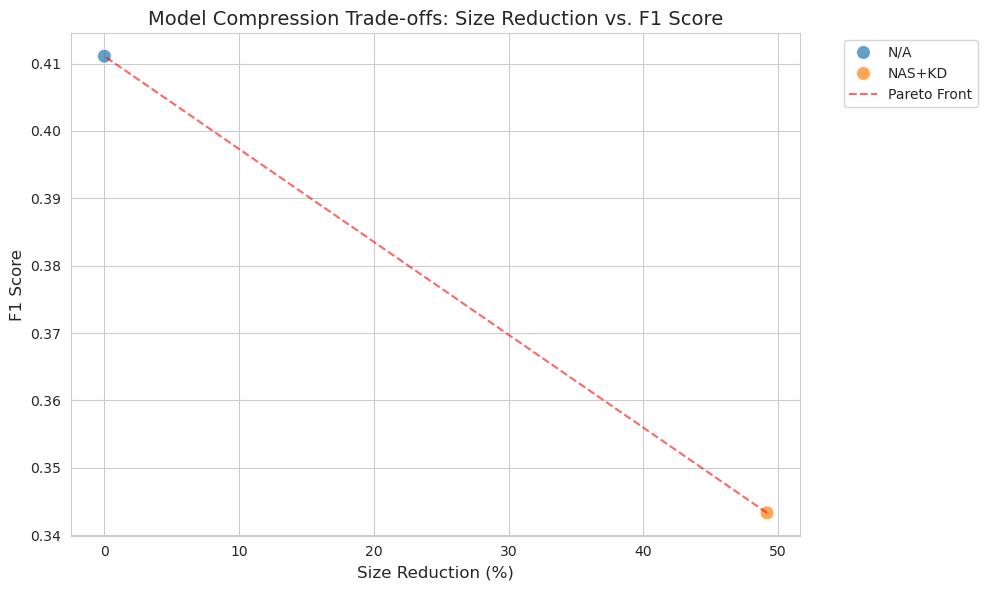

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet18)

# <span style="color: blue;">Algorithm Application to ResNet10t</span>
This section applied all of our KD algorithms to a pretrained ResNet10t.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: blue;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [17]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet10 = loader.load_radimagenet_resnet10t(
    "./trained_models/resnet10t_baseline_gpu_new/resnet10t_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet10 = resnet10.to(device)
resnet10.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet10.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet10, "ResNet10t gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet10t gpu new...
Running inference...
Our F1 score: 0.29770593570914206
Our total parameters: 4953781


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
# initialize a dataframe we will append our results to
results_df_resnet10 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df_resnet10
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df_resnet10 = pd.concat([results_df_resnet10, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet10t', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.298


## <span style="color: yellow;">b. Basic Compression Algorithms</span>

### Basic Pruning and Quantization

### Caylum - Lottery Ticket Hypothesis

### Kellie - RGP

## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>

### Ethan - NAS + KD Algorithm

In [19]:
''' search space:
input resolution = [112, 128, 160, 224]
depth = [1, 2, 3]
width = [0.5, 0.75, 1.0, 1.2]
'''
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet10'

        # supernet init params
        self.supernet_res = [112, 128, 160, 224]
        self.supernet_width = [0.5, 0.75, 1.0, 1.2]
        self.supernet_depth = [1, 2]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 2.0
        self.alpha = 0.2
        
        self.saver = 'supernet_resnet10_n'

In [20]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet10
from knowledge_distillation.extraction_tools import extract_resnet10, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet10(config.supernet_width, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'supernet_resnet10_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.5, 
    'depth': [2, 2, 2, 2],
    }

# extract our winning configuration from the supernet and confirm it loaded appropriately
standalone_r10 = extract_resnet10(snet, winning_config)
verify_parity(snet, standalone_r10, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(standalone_r10)
print(f'\nStudent model has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet10t',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])


Supernet loaded
Slicing weights for width 0.5 and depth [2, 2, 2, 2]...
The models match! Test is passed.
Max difference: 2.98e-07

Student model has parameters: 2819693
Logged: NAS+KD | Reduction: 43.1% | F1: 0.331


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD

## <span style="color: blue;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

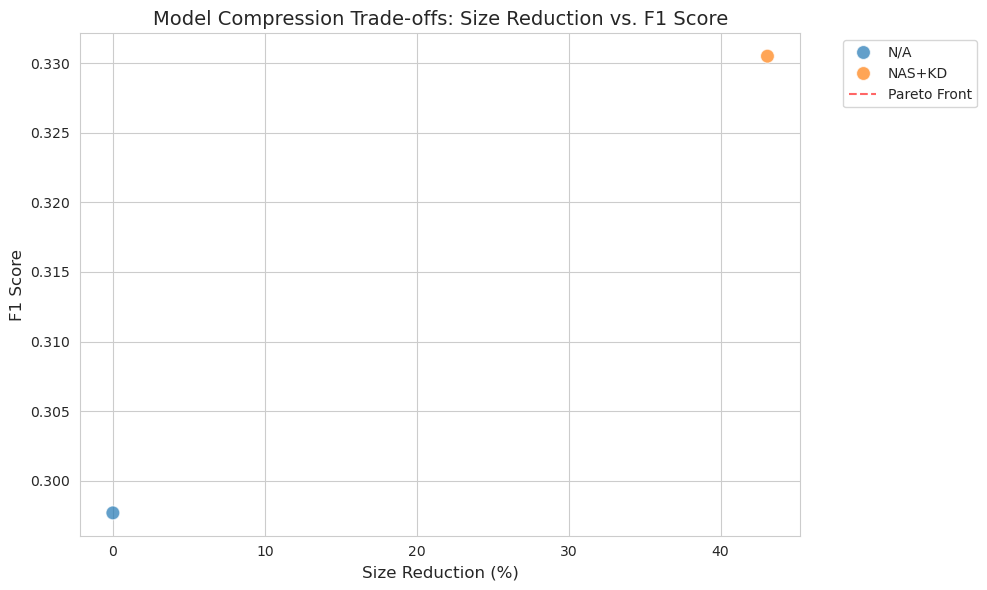

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet10)

In [ ]:
# Thank you!

# 5. Appendix

Ethan - below are the supernet training, evolutionary search, and finetuning results for the resNet18 and ResNet10t experiments

### ResNet18 NAS+KD Output

In [9]:
import torch.optim as optim
from torch.optim.lr_scheduler import ConstantLR, CosineAnnealingLR, SequentialLR, LinearLR

# main function to orchestrate supernet training - all the functions will be pulled from knowledge_distillation folder
def main(config, snet, optimizer, scheduler, start_epoch=0):
    #train_loader, search_loader, test_loader = get_data_loaders(data_directory, batch_size = batch_size)
    train_loader = data_prep.train_loader
    val_loader = data_prep.val_loader
    best_val_f1 = 0.0
    
    for epoch in range(start_epoch, config.epochs):        
        stats, phase = train_supernet(snet, 
                                      resnet18,  # this is where we pass teacher
                                      config, 
                                      train_loader, 
                                      optimizer, 
                                      epoch)  # weights distillation loss
        
        # validate every 5 epochs
        if (epoch + 1) % 5 == 0:
            val_stats = validate_supernet(snet, train_loader, val_loader, config)
            print(f"--- VALIDATION Epoch {epoch} ---")
            print(f"MAX Path: Acc {val_stats['MAX']['accuracy']:.2f}% | Loss {val_stats['MAX']['avg_loss']:.4f} | F1: {val_stats['MAX']['f1_macro']:.2f}")
            print(f"MIN Path: Acc {val_stats['MIN']['accuracy']:.2f}% | Loss {val_stats['MIN']['avg_loss']:.4f} | F1: {val_stats['MIN']['f1_macro']:.2f}")
            
            if val_stats['MAX']['f1_macro'] > best_val_f1:
                    print(f"New Best F1! Saving model...")
                    best_val_f1 = val_stats['MAX']['f1_macro']
                    
                    # Save the 'Best' version separately
                    save_path = f"{config.saver}_BEST_f1.pth"
                    
                    # Package it with metadata so you know which epoch it came from
                    checkpoint = {
                        'epoch': epoch,
                        'model_state_dict': snet.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'f1_macro': best_val_f1
                    }
                    torch.save(checkpoint, save_path)
        
        scheduler.step()
        
        # report epoch stats
        print(f"Epoch {epoch} | {phase} | LR: {scheduler.get_last_lr()[0]:.6f} | Loss: {stats['avg_loss']:.4f} | KL (Soft): {stats['avg_kl']:.4f} | Accuracy: {stats['accuracy']:.2f}%  | F1: {stats['f1_macro']:.2f}")
        
        # save every 5 epochs if loss is improving
        if (epoch+1)%5 == 0:
            save_supernet(snet, f'{config.saver}_epoch_{epoch+1}.pth')

In [10]:
from knowledge_distillation.model_init import Supernet_resnet18, save_supernet
from knowledge_distillation.train_loop import DistillationLoss, sample_configs, train_supernet, validate_supernet
# initialize config class
config = SupernetConfig()

# initialize our supernet model
snet = Supernet_resnet18(config.supernet_width, num_classes=config.num_data_classes)
num_params = sum(p.numel() for p in snet.parameters())
print("Parameters:", num_params)
print("Estimated FP32 size:", num_params * 4 / 1024**3, "GB")  # estimates size of supernet

snet.to(config.device)
# print(Supernet)  # confirm object

# optimizer and LR scheduler
optimizer = optim.SGD(snet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_warmup = ConstantLR(optimizer, factor=1.0, total_iters=config.warmup_epochs) # keep LR constant over warmup epochs
scheduler_cosine = CosineAnnealingLR(optimizer, T_max=(config.epochs - config.warmup_epochs), eta_min=1e-4)  # decay 0.05 -> 0.0001
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine],  milestones=[config.warmup_epochs])

main(config, snet, optimizer, scheduler)

Parameters: 25115141
Estimated FP32 size: 0.09356119111180305 GB
Epoch 0 | warm | LR: 0.010000 | Loss: 5.0617 | KL (Soft): 6.8294 | Accuracy: 8.18%  | F1: 0.07
Epoch 1 | warm | LR: 0.010000 | Loss: 4.0563 | KL (Soft): 5.0025 | Accuracy: 15.16%  | F1: 0.13
Epoch 2 | warm | LR: 0.010000 | Loss: 3.5989 | KL (Soft): 4.2298 | Accuracy: 19.63%  | F1: 0.18
Epoch 3 | warm | LR: 0.010000 | Loss: 3.3051 | KL (Soft): 3.7761 | Accuracy: 24.47%  | F1: 0.22
Recalibrating BN for MAX path...
Recalibrating BN for MIN path...
--- VALIDATION Epoch 4 ---
MAX Path: Acc 15.41% | Loss 3.0476 | F1: 0.14
MIN Path: Acc 14.59% | Loss 2.8073 | F1: 0.13
New Best F1! Saving model...
Epoch 4 | warm | LR: 0.010000 | Loss: 3.1608 | KL (Soft): 3.4994 | Accuracy: 25.72%  | F1: 0.23
Epoch 5 | warm | LR: 0.010000 | Loss: 2.9707 | KL (Soft): 3.2372 | Accuracy: 29.84%  | F1: 0.27
Epoch 6 | warm | LR: 0.010000 | Loss: 2.8493 | KL (Soft): 3.0300 | Accuracy: 31.93%  | F1: 0.29
Epoch 7 | warm | LR: 0.010000 | Loss: 2.7260 | KL 

In [11]:
import knowledge_distillation.evolutionary_search as es

# define size limit - about the size of the current resnet18
PARAM_LIMIT = 11.0

# load best supernet weights from training
snet = Supernet_resnet18(config.supernet_width, num_classes=config.num_data_classes)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location='cuda')
snet.load_state_dict(checkpoint['model_state_dict'])
snet.to('cuda')
snet.eval()

# intialize data loaders
train_loader = data_prep.train_loader
search_loader = data_prep.val_loader

# execute search
print(f"Starting Evolutionary Search")
best_architecture = es.run_evolutionary_search(
    snet, search_loader, train_loader, 'cuda', config,
    generations=10, 
    population_size=30, 
    param_limit=PARAM_LIMIT,    
)

print("\n--- Done Searching ---")
print(f"Final F1: {best_architecture['f1']:.4f}")
print(f"Final Size: {best_architecture['size']:.2f}M")
print(f"Best Config: {best_architecture['config']}")

Starting Evolutionary Search

--- Generation 0 ---
NEW BEST ARCHITECTURE
F1: 0.3595 | Size: 6.27M params
Config: {'res': 128, 'width': 0.75, 'depth': [1, 2, 2, 2]}

--- Generation 1 ---

--- Generation 2 ---
NEW BEST ARCHITECTURE
F1: 0.3656 | Size: 5.68M params
Config: {'res': 128, 'width': 0.75, 'depth': [3, 2, 1, 2]}

--- Generation 3 ---

--- Generation 4 ---

--- Generation 5 ---

--- Generation 6 ---

--- Generation 7 ---

--- Generation 8 ---

--- Generation 9 ---

--- Done Searching ---
Final F1: 0.3656
Final Size: 5.68M
Best Config: {'res': 128, 'width': 0.75, 'depth': [3, 2, 1, 2]}


In [18]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import f1_score
from knowledge_distillation.train_loop import DistillationLoss

winning_config = {
    'res': 128, 
    'width': 0.75, 
    'depth': [3, 2, 1, 2],
    }

EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-4  # AdamW handles smaller LRs better for fine-tuning
ALPHA = 0.0
TEMPERATURE = 3.0

# --- 2. INITIALIZE MODELS ---
# Initialize Supernet (using your project's cfg for consistency)
snet = Supernet_resnet18(config.supernet_width, num_classes=config.num_data_classes).to(config.device)

# Load the best weights found during the Evolutionary Search
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

for m in snet.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.momentum = 0.5  # Standard is 0.1; 0.5 makes it adapt 5x faster to the 128px path

# Initialize Teacher (Ensure resnet50 is loaded in your environment)
resnet18.to(config.device)
resnet18.eval()

# --- 3. OPTIMIZER, SCHEDULER, & LOSS ---
optimizer = optim.AdamW(snet.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = DistillationLoss(alpha=ALPHA, T=TEMPERATURE)

def evaluate_f1(model, cfg, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(config.device), labels.to(config.device)
            # Match resolution
            if images.shape[-1] != cfg['res']:
                images = F.interpolate(images, size=(cfg['res'], cfg['res']), mode='bilinear')
            
            logits = model(images, cfg)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return f1_score(all_labels, all_preds, average='macro', zero_division=0)

# --- 5. FINE-TUNING LOOP ---
best_f1 = 0.3 # Starting benchmark from GA

for epoch in range(EPOCHS):
    snet.train()
    running_loss = 0.0
    
    for images, labels in data_prep.train_loader:
        images, labels = images.to(config.device), labels.to(config.device)
        
        # Match resolution to the winning config
        if images.shape[-1] != winning_config['res']:
            images = F.interpolate(images, size=(winning_config['res'], winning_config['res']), mode='bilinear')
        
        optimizer.zero_grad()
        
        # Forward passes
        with torch.no_grad():
            teacher_logits = resnet18(images)
        
        student_logits = snet(images, winning_config)
        
        # Loss & Backprop
        loss, _ = criterion(student_logits, teacher_logits, labels)
        loss.backward()
        
        # Clip grads for stability in medical 61-class space
        torch.nn.utils.clip_grad_norm_(snet.parameters(), max_norm=2.0)
        optimizer.step()
        
        running_loss += loss.item()

    # Step Scheduler & Evaluate
    scheduler.step()
    
    snet.train()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(data_prep.train_loader):
            if i > 40: break # Quick calibration
            if imgs.shape[-1] != winning_config['res']:
                imgs = F.interpolate(imgs, size=(winning_config['res'], winning_config['res']), mode='bilinear')
            _ = snet(imgs.to(device), winning_config)

    # NOW run the evaluation
    current_f1 = evaluate_f1(snet, winning_config, data_prep.val_loader, config.device)
    avg_loss = running_loss / len(data_prep.train_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {current_f1:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    # Save if we hit a new peak
    if current_f1 > best_f1:
        best_f1 = current_f1
        print(f"New Best Fine-Tuned F1: {best_f1:.4f}, Saving...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': snet.state_dict(),
            'config': winning_config,
            'f1_macro': best_f1
        }, f"{config.saver}_polished.pth")

print("\nThat's all.")

Supernet loaded
Epoch 1/30 | Loss: 1.5887 | Val F1: 0.3482 | LR: 0.000100
New Best Fine-Tuned F1: 0.3482, Saving...
Epoch 2/30 | Loss: 1.4613 | Val F1: 0.3395 | LR: 0.000099
Epoch 3/30 | Loss: 1.4193 | Val F1: 0.3328 | LR: 0.000098
Epoch 4/30 | Loss: 1.3547 | Val F1: 0.3487 | LR: 0.000096
New Best Fine-Tuned F1: 0.3487, Saving...
Epoch 5/30 | Loss: 1.3139 | Val F1: 0.3575 | LR: 0.000093
New Best Fine-Tuned F1: 0.3575, Saving...
Epoch 6/30 | Loss: 1.3005 | Val F1: 0.3152 | LR: 0.000090
Epoch 7/30 | Loss: 1.2648 | Val F1: 0.3332 | LR: 0.000087
Epoch 8/30 | Loss: 1.2481 | Val F1: 0.3587 | LR: 0.000083
New Best Fine-Tuned F1: 0.3587, Saving...
Epoch 9/30 | Loss: 1.2298 | Val F1: 0.3658 | LR: 0.000079
New Best Fine-Tuned F1: 0.3658, Saving...
Epoch 10/30 | Loss: 1.2061 | Val F1: 0.3508 | LR: 0.000075
Epoch 11/30 | Loss: 1.1626 | Val F1: 0.3538 | LR: 0.000070
Epoch 12/30 | Loss: 1.1650 | Val F1: 0.3469 | LR: 0.000065
Epoch 13/30 | Loss: 1.1219 | Val F1: 0.3768 | LR: 0.000060
New Best Fine-Tu

### ResNet10t NAS+KD Logs

In [55]:
# define our training orchestration function
import torch.optim as optim
from torch.optim.lr_scheduler import ConstantLR, CosineAnnealingLR, SequentialLR, LinearLR

# main function to orchestrate supernet training - all the functions will be pulled from knowledge_distillation folder
def main(config, snet, optimizer, scheduler, start_epoch=0):
    #train_loader, search_loader, test_loader = get_data_loaders(data_directory, batch_size = batch_size)
    train_loader = data_prep.train_loader
    val_loader = data_prep.val_loader
    best_val_f1 = 0.0
    
    for epoch in range(start_epoch, config.epochs):        
        stats, phase = train_supernet(snet, 
                                      resnet10,  # this is where we pass teacher
                                      config, 
                                      train_loader, 
                                      optimizer, 
                                      epoch)  # weights distillation loss
        
        # validate every 5 epochs
        if (epoch + 1) % 5 == 0:
            val_stats = validate_supernet(snet, train_loader, val_loader, config)
            print(f"--- VALIDATION Epoch {epoch} ---")
            print(f"MAX Path: Acc {val_stats['MAX']['accuracy']:.2f}% | Loss {val_stats['MAX']['avg_loss']:.4f} | F1: {val_stats['MAX']['f1_macro']:.2f}")
            print(f"MIN Path: Acc {val_stats['MIN']['accuracy']:.2f}% | Loss {val_stats['MIN']['avg_loss']:.4f} | F1: {val_stats['MIN']['f1_macro']:.2f}")
            
            if val_stats['MAX']['f1_macro'] > best_val_f1:
                    print(f"New Best F1! Saving model...")
                    best_val_f1 = val_stats['MAX']['f1_macro']
                    
                    # Save the 'Best' version separately
                    save_path = f"{config.saver}_BEST_f1.pth"
                    
                    # Package it with metadata so you know which epoch it came from
                    checkpoint = {
                        'epoch': epoch,
                        'model_state_dict': snet.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'f1_macro': best_val_f1
                    }
                    torch.save(checkpoint, save_path)
        
        scheduler.step()
        
        # report epoch stats
        print(f"Epoch {epoch} | {phase} | LR: {scheduler.get_last_lr()[0]:.6f} | Loss: {stats['avg_loss']:.4f} | KL (Soft): {stats['avg_kl']:.4f} | Accuracy: {stats['accuracy']:.2f}%  | F1: {stats['f1_macro']:.2f}")
        
        # save every 5 epochs if loss is improving
        if (epoch+1)%5 == 0:
            save_supernet(snet, f'{config.saver}_epoch_{epoch+1}.pth')

In [59]:
from knowledge_distillation.model_init import Supernet_resnet10, save_supernet
from knowledge_distillation.train_loop import DistillationLoss, sample_configs, train_supernet, validate_supernet
# initialize config class
config = SupernetConfig()

# initialize our supernet model
snet = Supernet_resnet10(config.supernet_width, num_classes=config.num_data_classes)
num_params = sum(p.numel() for p in snet.parameters())
print("Parameters:", num_params)
print("Estimated FP32 size:", num_params * 4 / 1024**3, "GB")  # estimates size of supernet

snet.to(config.device)
# print(Supernet)  # confirm object

# optimizer and LR scheduler
optimizer = optim.SGD(snet.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-3)
scheduler_warmup = ConstantLR(optimizer, factor=1.0, total_iters=config.warmup_epochs) # keep LR constant over warmup epochs
scheduler_cosine = CosineAnnealingLR(optimizer, T_max=(config.epochs - config.warmup_epochs), eta_min=1e-4)  # decay 0.05 -> 0.0001
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_cosine],  milestones=[config.warmup_epochs])

main(config, snet, optimizer, scheduler)

Parameters: 16129571
Estimated FP32 size: 0.060087334364652634 GB
Epoch 0 | warm | LR: 0.010000 | Loss: 4.0306 | KL (Soft): 4.9784 | Accuracy: 8.27%  | F1: 0.07
Epoch 1 | warm | LR: 0.010000 | Loss: 3.2902 | KL (Soft): 3.4669 | Accuracy: 17.30%  | F1: 0.16
Epoch 2 | warm | LR: 0.010000 | Loss: 2.9793 | KL (Soft): 2.9065 | Accuracy: 22.22%  | F1: 0.20
Epoch 3 | warm | LR: 0.010000 | Loss: 2.7954 | KL (Soft): 2.5943 | Accuracy: 26.25%  | F1: 0.24
Recalibrating BN for MAX path...
Recalibrating BN for MIN path...
--- VALIDATION Epoch 4 ---
MAX Path: Acc 19.18% | Loss 2.7162 | F1: 0.14
MIN Path: Acc 18.49% | Loss 2.7873 | F1: 0.15
New Best F1! Saving model...
Epoch 4 | warm | LR: 0.010000 | Loss: 2.6487 | KL (Soft): 2.3282 | Accuracy: 30.11%  | F1: 0.27
Epoch 5 | warm | LR: 0.010000 | Loss: 2.5781 | KL (Soft): 2.2306 | Accuracy: 31.37%  | F1: 0.28
Epoch 6 | warm | LR: 0.010000 | Loss: 2.4912 | KL (Soft): 2.0825 | Accuracy: 34.16%  | F1: 0.31
Epoch 7 | warm | LR: 0.010000 | Loss: 2.4157 | KL

In [24]:
from knowledge_distillation.model_init import Supernet_resnet10, save_supernet
import knowledge_distillation.evolutionary_search as es

# define size limit - about the size of the current resnet18
PARAM_LIMIT = 5.0
config = SupernetConfig()

# load best supernet weights from training
snet = Supernet_resnet10(config.supernet_width, num_classes=config.num_data_classes)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location='cuda')
snet.load_state_dict(checkpoint['model_state_dict'])
snet.to('cuda')
snet.eval()

# intialize data loaders
train_loader = data_prep.train_loader
search_loader = data_prep.val_loader

# execute search
print(f"Starting Evolutionary Search")
best_architecture = es.run_evolutionary_search(
    snet, search_loader, train_loader, 'cuda', config,
    generations=10, 
    population_size=30, 
    param_limit=PARAM_LIMIT,    
)

print("\n--- Done Searching ---")
print(f"Final F1: {best_architecture['f1']:.4f}")
print(f"Final Size: {best_architecture['size']:.2f}M")
print(f"Best Config: {best_architecture['config']}")

Starting Evolutionary Search

--- Generation 0 ---
NEW BEST ARCHITECTURE
F1: 0.3505 | Size: 3.49M params
Config: {'res': 112, 'width': 0.75, 'depth': [2, 1, 2, 1]}

--- Generation 1 ---

--- Generation 2 ---
NEW BEST ARCHITECTURE
F1: 0.3572 | Size: 2.81M params
Config: {'res': 128, 'width': 0.5, 'depth': [2, 2, 2, 2]}

--- Generation 3 ---

--- Generation 4 ---
NEW BEST ARCHITECTURE
F1: 0.3588 | Size: 2.81M params
Config: {'res': 128, 'width': 0.5, 'depth': [2, 2, 2, 2]}

--- Generation 5 ---
NEW BEST ARCHITECTURE
F1: 0.3597 | Size: 2.81M params
Config: {'res': 128, 'width': 0.5, 'depth': [2, 2, 2, 2]}

--- Generation 6 ---

--- Generation 7 ---

--- Generation 8 ---

--- Generation 9 ---

--- Done Searching ---
Final F1: 0.3597
Final Size: 2.81M
Best Config: {'res': 128, 'width': 0.5, 'depth': [2, 2, 2, 2]}


In [33]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import f1_score
from knowledge_distillation.train_loop import DistillationLoss, evaluate_f1

winning_config = {
    'res': 128, 
    'width': 0.5, 
    'depth': [2, 2, 2, 2],
    }

EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
ALPHA = 0.0
TEMPERATURE = 3.0

# initialize supernet and load best weights from supernet training
snet = Supernet_resnet10(config.supernet_width, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'{config.saver}_BEST_f1.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

for m in snet.modules():
    if isinstance(m, nn.BatchNorm2d):
        m.momentum = 0.5  # make batch normalization faster to adapt to new data

# confirm teacher is ready - turns out to be useless, since we set our alpha to zero
resnet10.to(config.device)
resnet10.eval()

# instantiate optimizer, scheduler, loss
optimizer = optim.AdamW(snet.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = DistillationLoss(alpha=ALPHA, T=TEMPERATURE)


# fine tuning loop
best_f1 = 0.0 # starting benchmark

for epoch in range(EPOCHS):
    snet.train()
    running_loss = 0.0
    
    for images, labels in data_prep.train_loader:
        images, labels = images.to(config.device), labels.to(config.device)
        
        # match input resolution to the winning config
        if images.shape[-1] != winning_config['res']:
            images = F.interpolate(images, size=(winning_config['res'], winning_config['res']), mode='bilinear')
        
        optimizer.zero_grad()
        
        # forward pass for teacher and student
        with torch.no_grad():
            teacher_logits = resnet10(images)
        student_logits = snet(images, winning_config)
        
        # loss and backprop
        loss, _ = criterion(student_logits, teacher_logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(snet.parameters(), max_norm=2.0)  # gradient clipping
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    
    snet.train()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(data_prep.train_loader):
            if i > 40: break # quick recalibration
            if imgs.shape[-1] != winning_config['res']:
                imgs = F.interpolate(imgs, size=(winning_config['res'], winning_config['res']), mode='bilinear')
            _ = snet(imgs.to(device), winning_config)

    # run the evaluation
    current_f1 = evaluate_f1(snet, winning_config, data_prep.val_loader, config.device)
    avg_loss = running_loss / len(data_prep.train_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {current_f1:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    # save if we hit a new peak
    if current_f1 > best_f1:
        best_f1 = current_f1
        print(f"New Best Fine-Tuned F1: {best_f1:.4f}, Saving...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': snet.state_dict(),
            'config': winning_config,
            'f1_macro': best_f1
        }, f"{config.saver}_polished.pth")

print("\nThat's all.")

Supernet loaded
Epoch 1/30 | Loss: 1.4991 | Val F1: 0.3386 | LR: 0.000100
New Best Fine-Tuned F1: 0.3386, Saving...
Epoch 2/30 | Loss: 1.3883 | Val F1: 0.3541 | LR: 0.000099
New Best Fine-Tuned F1: 0.3541, Saving...
Epoch 3/30 | Loss: 1.3503 | Val F1: 0.3635 | LR: 0.000098
New Best Fine-Tuned F1: 0.3635, Saving...
Epoch 4/30 | Loss: 1.3150 | Val F1: 0.3606 | LR: 0.000096
Epoch 5/30 | Loss: 1.2780 | Val F1: 0.3341 | LR: 0.000093
Epoch 6/30 | Loss: 1.2617 | Val F1: 0.3388 | LR: 0.000090
Epoch 7/30 | Loss: 1.2357 | Val F1: 0.3508 | LR: 0.000087
Epoch 8/30 | Loss: 1.2263 | Val F1: 0.3550 | LR: 0.000083
Epoch 9/30 | Loss: 1.1850 | Val F1: 0.3477 | LR: 0.000079
Epoch 10/30 | Loss: 1.1716 | Val F1: 0.3788 | LR: 0.000075
New Best Fine-Tuned F1: 0.3788, Saving...
Epoch 11/30 | Loss: 1.1460 | Val F1: 0.3705 | LR: 0.000070
Epoch 12/30 | Loss: 1.1456 | Val F1: 0.3550 | LR: 0.000065
Epoch 13/30 | Loss: 1.1259 | Val F1: 0.3784 | LR: 0.000060
Epoch 14/30 | Loss: 1.0793 | Val F1: 0.3807 | LR: 0.000055